# Train a CIFAR-100 image baseline

This notebook fine-tunes an ImageNet-pretrained **ConvNeXt-Tiny** classifier on CIFAR-100 and measures held-out image-classification accuracy. The initial research target is about **90% clean top-1 accuracy**, but that is a target—not a result. Always report the accuracy produced by the run.

The notebook also exports logits, probabilities, and penultimate-layer embeddings for later temperature-scaling and SDM experiments. It does **not** implement SDM or claim reliability under corruption or distribution shift.

> Full benchmark: run the notebook normally. Bounded pipeline check: launch Jupyter with `SDM_RUN_MODE=smoke`; smoke metrics cover only a few batches and are not benchmark results.


## Experimental separation

The official 50,000-image CIFAR-100 training set is deterministically divided within every class:

- **45,000 training images** (450/class): gradient updates only
- **2,500 validation images** (25/class): checkpoint selection only
- **2,500 calibration images** (25/class): reserved for later calibration/threshold fitting
- **10,000 official test images** (100/class): final held-out evaluation only

The calibration and test sets never influence training or checkpoint selection. Downloads, checkpoints, and generated arrays live under `~/.cache/sdm-vision-reliability/` by default, outside this Git repository.


In [1]:
from __future__ import annotations

import json
import os
import platform
import random
import subprocess
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import ConvNeXt_Tiny_Weights, convnext_tiny
from torchvision.transforms import InterpolationMode

RUN_MODE = os.environ.get("SDM_RUN_MODE", "benchmark").strip().lower()
if RUN_MODE not in {"benchmark", "smoke"}:
    raise ValueError("SDM_RUN_MODE must be 'benchmark' or 'smoke'.")

SEED = 42
MODEL_NAME = "convnext_tiny_imagenet1k_v1"
DATA_DIR = Path(os.environ.get(
    "SDM_DATA_DIR", Path.home() / ".cache" / "sdm-vision-reliability"
)).expanduser()
RUN_DIR = Path(os.environ.get(
    "SDM_RUN_DIR",
    Path.home() / ".cache" / "sdm-vision-reliability" / "runs" / MODEL_NAME / f"seed_{SEED}" / RUN_MODE,
)).expanduser()
DATA_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)

SMOKE = RUN_MODE == "smoke"
IMAGE_SIZE = 224
BATCH_SIZE = 8 if SMOKE else 128
EPOCHS = 1 if SMOKE else 20
MAX_TRAIN_BATCHES = 2 if SMOKE else None
MAX_EVAL_BATCHES = 2 if SMOKE else None
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.05
LABEL_SMOOTHING = 0.1
NUM_WORKERS = 0 if platform.system() in {"Windows", "Darwin"} else min(4, os.cpu_count() or 1)
FORCE_RETRAIN = os.environ.get("SDM_FORCE_RETRAIN", "0") == "1"

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
USE_AMP = DEVICE.type == "cuda"

CONFIG = {
    "run_mode": RUN_MODE,
    "seed": SEED,
    "model_name": MODEL_NAME,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "label_smoothing": LABEL_SMOOTHING,
    "num_workers": NUM_WORKERS,
    "device": str(DEVICE),
    "max_train_batches": MAX_TRAIN_BATCHES,
    "max_eval_batches": MAX_EVAL_BATCHES,
}

print(json.dumps(CONFIG, indent=2))
print(f"Data: {DATA_DIR}")
print(f"Outputs: {RUN_DIR}")
if SMOKE:
    print("SMOKE MODE: metrics are intentionally incomplete and are not benchmark results.")


{
  "run_mode": "benchmark",
  "seed": 42,
  "model_name": "convnext_tiny_imagenet1k_v1",
  "image_size": 224,
  "batch_size": 128,
  "epochs": 20,
  "learning_rate": 0.0003,
  "weight_decay": 0.05,
  "label_smoothing": 0.1,
  "num_workers": 4,
  "device": "cuda",
  "max_train_batches": null,
  "max_eval_batches": null
}
Data: /home/randy/.cache/sdm-vision-reliability
Outputs: /home/randy/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/benchmark


## Reproducibility controls

Seeds and deterministic backend settings reduce variation. Exact GPU results can still vary across hardware, drivers, and library builds, so the exported metadata records those versions.


In [2]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True


seed_everything(SEED)


## Load CIFAR-100 and construct disjoint splits

Training uses crop, flip, RandAugment, and random erasing. Validation, calibration, and test preprocessing is deterministic and matches the pretrained model's ImageNet normalization.


In [3]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE, scale=(0.65, 1.0), interpolation=InterpolationMode.BICUBIC
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25),
])

eval_transform = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_aug_base = datasets.CIFAR100(DATA_DIR, train=True, download=True, transform=train_transform)
train_eval_base = datasets.CIFAR100(DATA_DIR, train=True, download=False, transform=eval_transform)
test_dataset = datasets.CIFAR100(DATA_DIR, train=False, download=True, transform=eval_transform)

targets = np.asarray(train_aug_base.targets)
rng = np.random.default_rng(SEED)
train_indices, validation_indices, calibration_indices = [], [], []

for class_id in range(100):
    class_indices = np.flatnonzero(targets == class_id)
    class_indices = rng.permutation(class_indices)
    validation_indices.extend(class_indices[:25])
    calibration_indices.extend(class_indices[25:50])
    train_indices.extend(class_indices[50:])

train_indices = np.asarray(train_indices)
validation_indices = np.asarray(validation_indices)
calibration_indices = np.asarray(calibration_indices)

assert len(train_indices) == 45_000
assert len(validation_indices) == 2_500
assert len(calibration_indices) == 2_500
assert not (set(train_indices) & set(validation_indices))
assert not (set(train_indices) & set(calibration_indices))
assert not (set(validation_indices) & set(calibration_indices))

train_dataset = Subset(train_aug_base, train_indices)
validation_dataset = Subset(train_eval_base, validation_indices)
calibration_dataset = Subset(train_eval_base, calibration_indices)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": NUM_WORKERS > 0,
}
train_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, shuffle=True, generator=train_generator, **loader_options)
validation_loader = DataLoader(validation_dataset, shuffle=False, **loader_options)
calibration_loader = DataLoader(calibration_dataset, shuffle=False, **loader_options)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)

print({
    "training": len(train_dataset),
    "validation": len(validation_dataset),
    "calibration": len(calibration_dataset),
    "test": len(test_dataset),
})


{'training': 45000, 'validation': 2500, 'calibration': 2500, 'test': 10000}


In [4]:
images, labels = next(iter(train_loader))
print("Batch images:", tuple(images.shape), images.dtype)
print("Batch labels:", tuple(labels.shape), labels.dtype)
print("First labels:", [train_aug_base.classes[index] for index in labels[:8].tolist()])


Batch images: (128, 3, 224, 224) torch.float32
Batch labels: (128,) torch.int64
First labels: ['rose', 'bicycle', 'flatfish', 'palm_tree', 'crocodile', 'tulip', 'woman', 'otter']


## Initialize the classifier

ConvNeXt-Tiny starts from the fixed `IMAGENET1K_V1` weights included with torchvision 0.22.1. Only its final linear layer is replaced; all layers are fine-tuned. This transfer-learning baseline is more likely to approach the clean-data target than a short from-scratch training run.


In [5]:
weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
model = convnext_tiny(weights=weights)
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, 100)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f"Parameters: {total_parameters:,} total; {trainable_parameters:,} trainable")


Parameters: 27,897,028 total; 27,897,028 trainable


## Train and select the checkpoint

The best checkpoint is selected using validation top-1 accuracy. The calibration and test loaders are not touched in this loop. Existing checkpoints are reused unless Jupyter is launched with `SDM_FORCE_RETRAIN=1`.


In [6]:
def classification_epoch(loader, *, training: bool, max_batches: int | None = None) -> dict:
    model.train(training)
    total_loss = 0.0
    total_examples = 0
    top1_correct = 0
    top5_correct = 0

    for batch_number, (inputs, targets_batch) in enumerate(loader):
        if max_batches is not None and batch_number >= max_batches:
            break
        inputs = inputs.to(DEVICE, non_blocking=True)
        targets_batch = targets_batch.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
                logits = model(inputs)
                loss = criterion(logits, targets_batch)

            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        batch_size = targets_batch.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size
        top5 = logits.topk(5, dim=1).indices
        top1_correct += (top5[:, 0] == targets_batch).sum().item()
        top5_correct += (top5 == targets_batch[:, None]).any(dim=1).sum().item()

    return {
        "loss": total_loss / total_examples,
        "top1_accuracy": top1_correct / total_examples,
        "top5_accuracy": top5_correct / total_examples,
        "examples": total_examples,
    }


In [7]:
checkpoint_path = RUN_DIR / "best_checkpoint.pt"
history = []
best_validation_accuracy = -1.0

checkpoint = None
if checkpoint_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
checkpoint_is_complete = bool(checkpoint and checkpoint.get("training_complete", False))

if checkpoint_is_complete and not FORCE_RETRAIN:
    model.load_state_dict(checkpoint["model_state_dict"])
    history = checkpoint.get("history", [])
    best_validation_accuracy = checkpoint["best_validation_accuracy"]
    print(f"Loaded existing checkpoint: {checkpoint_path}")
else:
    started = time.time()
    for epoch in range(1, EPOCHS + 1):
        train_metrics = classification_epoch(
            train_loader, training=True, max_batches=MAX_TRAIN_BATCHES
        )
        validation_metrics = classification_epoch(
            validation_loader, training=False, max_batches=MAX_EVAL_BATCHES
        )
        scheduler.step()

        epoch_record = {
            "epoch": epoch,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "train": train_metrics,
            "validation": validation_metrics,
        }
        history.append(epoch_record)
        print(
            f"Epoch {epoch:02d}/{EPOCHS}: "
            f"train top-1={train_metrics['top1_accuracy']:.3%}, "
            f"validation top-1={validation_metrics['top1_accuracy']:.3%}"
        )

        if validation_metrics["top1_accuracy"] > best_validation_accuracy:
            best_validation_accuracy = validation_metrics["top1_accuracy"]
            torch.save({
                "model_state_dict": model.state_dict(),
                "best_validation_accuracy": best_validation_accuracy,
                "history": history,
                "config": CONFIG,
                "class_names": train_aug_base.classes,
                "training_complete": False,
            }, checkpoint_path)

    elapsed_minutes = (time.time() - started) / 60
    print(f"Training completed in {elapsed_minutes:.1f} minutes")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    checkpoint["training_complete"] = True
    checkpoint["completed_epochs"] = EPOCHS
    torch.save(checkpoint, checkpoint_path)
    model.load_state_dict(checkpoint["model_state_dict"])

print(f"Best validation top-1: {best_validation_accuracy:.3%}")


Epoch 01/20: train top-1=64.040%, validation top-1=80.000%
Epoch 02/20: train top-1=78.864%, validation top-1=82.720%
Epoch 03/20: train top-1=83.009%, validation top-1=85.000%
Epoch 04/20: train top-1=86.153%, validation top-1=84.760%
Epoch 05/20: train top-1=88.098%, validation top-1=83.440%
Epoch 06/20: train top-1=89.836%, validation top-1=85.720%
Epoch 07/20: train top-1=91.427%, validation top-1=85.280%
Epoch 08/20: train top-1=92.647%, validation top-1=85.280%
Epoch 09/20: train top-1=93.853%, validation top-1=85.120%
Epoch 10/20: train top-1=94.680%, validation top-1=86.800%
Epoch 11/20: train top-1=95.602%, validation top-1=85.800%
Epoch 12/20: train top-1=95.998%, validation top-1=87.200%
Epoch 13/20: train top-1=96.582%, validation top-1=87.240%
Epoch 14/20: train top-1=97.373%, validation top-1=87.600%
Epoch 15/20: train top-1=97.733%, validation top-1=88.160%
Epoch 16/20: train top-1=97.884%, validation top-1=88.200%
Epoch 17/20: train top-1=98.247%, validation top-1=88.32

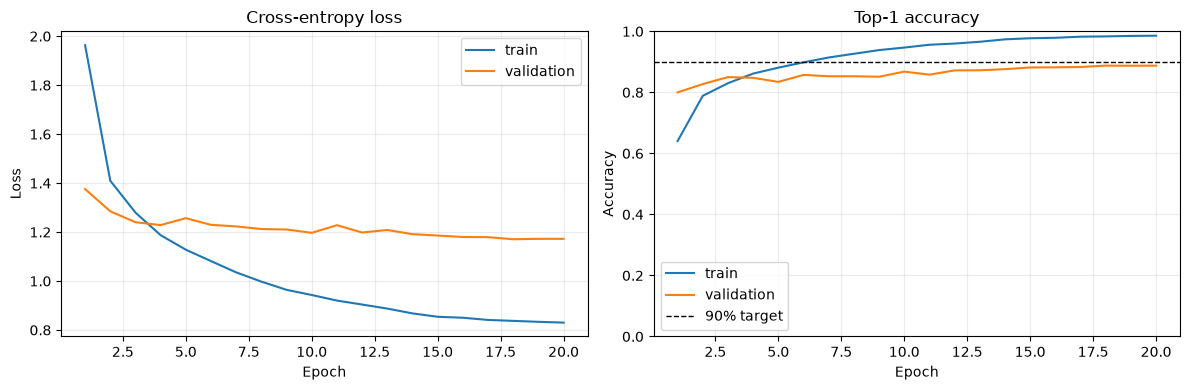

In [8]:
if history:
    epochs = [row["epoch"] for row in history]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, [row["train"]["loss"] for row in history], label="train")
    axes[0].plot(epochs, [row["validation"]["loss"] for row in history], label="validation")
    axes[0].set(title="Cross-entropy loss", xlabel="Epoch", ylabel="Loss")
    axes[1].plot(epochs, [row["train"]["top1_accuracy"] for row in history], label="train")
    axes[1].plot(epochs, [row["validation"]["top1_accuracy"] for row in history], label="validation")
    axes[1].axhline(0.90, color="black", linestyle="--", linewidth=1, label="90% target")
    axes[1].set(title="Top-1 accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1))
    for axis in axes:
        axis.grid(alpha=0.25)
        axis.legend()
    plt.tight_layout()
    plt.show()


## Export calibration and held-out test representations

The penultimate embedding is the normalized, pooled ConvNeXt representation immediately before the 100-class linear layer. Calibration exports are intended for later temperature scaling or SDM fitting. Test exports must remain evaluation-only.


In [9]:
@torch.inference_mode()
def collect_outputs(loader, *, max_batches: int | None = None) -> tuple[dict, dict]:
    model.eval()
    all_logits, all_probabilities = [], []
    all_embeddings, all_targets, all_predictions = [], [], []

    for batch_number, (inputs, targets_batch) in enumerate(loader):
        if max_batches is not None and batch_number >= max_batches:
            break
        inputs = inputs.to(DEVICE, non_blocking=True)
        targets_device = targets_batch.to(DEVICE, non_blocking=True)

        features = model.features(inputs)
        embeddings = model.avgpool(features)
        embeddings = model.classifier[0](embeddings)
        embeddings = model.classifier[1](embeddings)
        logits = model.classifier[2](embeddings)
        probabilities = logits.softmax(dim=1)
        predictions = logits.argmax(dim=1)

        all_logits.append(logits.cpu())
        all_probabilities.append(probabilities.cpu())
        all_embeddings.append(embeddings.cpu())
        all_targets.append(targets_batch.cpu())
        all_predictions.append(predictions.cpu())

    arrays = {
        "logits": torch.cat(all_logits).numpy(),
        "probabilities": torch.cat(all_probabilities).numpy(),
        "embeddings": torch.cat(all_embeddings).numpy(),
        "targets": torch.cat(all_targets).numpy(),
        "predictions": torch.cat(all_predictions).numpy(),
    }
    target_tensor = torch.from_numpy(arrays["targets"])
    logits_tensor = torch.from_numpy(arrays["logits"])
    top5 = logits_tensor.topk(5, dim=1).indices
    metrics = {
        "top1_accuracy": float((torch.from_numpy(arrays["predictions"]) == target_tensor).float().mean()),
        "top5_accuracy": float((top5 == target_tensor[:, None]).any(dim=1).float().mean()),
        "examples": int(len(target_tensor)),
    }
    return arrays, metrics


calibration_arrays, calibration_metrics = collect_outputs(
    calibration_loader, max_batches=MAX_EVAL_BATCHES
)
test_arrays, test_metrics = collect_outputs(test_loader, max_batches=MAX_EVAL_BATCHES)

suffix = "smoke" if SMOKE else "full"
calibration_path = RUN_DIR / f"calibration_outputs_{suffix}.npz"
test_path = RUN_DIR / f"test_outputs_{suffix}.npz"
np.savez_compressed(
    calibration_path,
    **calibration_arrays,
    class_names=np.asarray(train_aug_base.classes),
    dataset_indices=calibration_indices[: len(calibration_arrays["targets"])],
)
np.savez_compressed(
    test_path,
    **test_arrays,
    class_names=np.asarray(test_dataset.classes),
    dataset_indices=np.arange(len(test_arrays["targets"])),
)

print("Calibration:", calibration_metrics)
print("Test:", test_metrics)
print(f"Saved: {calibration_path}")
print(f"Saved: {test_path}")
if SMOKE:
    print("Reminder: these partial-batch smoke metrics are not benchmark results.")


Calibration: {'top1_accuracy': 0.8863999843597412, 'top5_accuracy': 0.9860000014305115, 'examples': 2500}
Test: {'top1_accuracy': 0.8896999955177307, 'top5_accuracy': 0.9815999865531921, 'examples': 10000}
Saved: /home/randy/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/benchmark/calibration_outputs_full.npz
Saved: /home/randy/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/benchmark/test_outputs_full.npz


In [10]:
def current_git_commit() -> str | None:
    try:
        return subprocess.run(
            ["git", "rev-parse", "HEAD"],
            check=True,
            capture_output=True,
            text=True,
        ).stdout.strip()
    except (OSError, subprocess.CalledProcessError):
        return None


metadata = {
    "config": CONFIG,
    "split_sizes": {
        "training": len(train_dataset),
        "validation": len(validation_dataset),
        "calibration": len(calibration_dataset),
        "test": len(test_dataset),
    },
    "best_validation_accuracy": best_validation_accuracy,
    "calibration_metrics": calibration_metrics,
    "test_metrics": test_metrics,
    "complete_benchmark": not SMOKE,
    "versions": {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "torchvision": torchvision.__version__,
        "numpy": np.__version__,
        "platform": platform.platform(),
    },
    "git_commit": current_git_commit(),
    "artifacts": {
        "checkpoint": str(checkpoint_path),
        "calibration_outputs": str(calibration_path),
        "test_outputs": str(test_path),
    },
}
metadata_path = RUN_DIR / f"run_metadata_{suffix}.json"
metadata_path.write_text(json.dumps(metadata, indent=2) + "\n", encoding="utf-8")
print(metadata_path.read_text())


{
  "config": {
    "run_mode": "benchmark",
    "seed": 42,
    "model_name": "convnext_tiny_imagenet1k_v1",
    "image_size": 224,
    "batch_size": 128,
    "epochs": 20,
    "learning_rate": 0.0003,
    "weight_decay": 0.05,
    "label_smoothing": 0.1,
    "num_workers": 4,
    "device": "cuda",
    "max_train_batches": null,
    "max_eval_batches": null
  },
  "split_sizes": {
    "training": 45000,
    "validation": 2500,
    "calibration": 2500,
    "test": 10000
  },
  "best_validation_accuracy": 0.8876,
  "calibration_metrics": {
    "top1_accuracy": 0.8863999843597412,
    "top5_accuracy": 0.9860000014305115,
    "examples": 2500
  },
  "test_metrics": {
    "top1_accuracy": 0.8896999955177307,
    "top5_accuracy": 0.9815999865531921,
    "examples": 10000
  },
  "complete_benchmark": true,
  "versions": {
    "python": "3.12.12",
    "torch": "2.7.1+cu128",
    "torchvision": "0.22.1+cu128",
    "numpy": "2.3.5",
    "platform": "Linux-7.2.6-arch2-1-x86_64-with-glibc2.44"
  

## Inspect class-level behavior

Overall accuracy can hide weak classes. This chart shows held-out top-1 accuracy by class. In smoke mode it reflects only the small partial test slice and should not be interpreted.


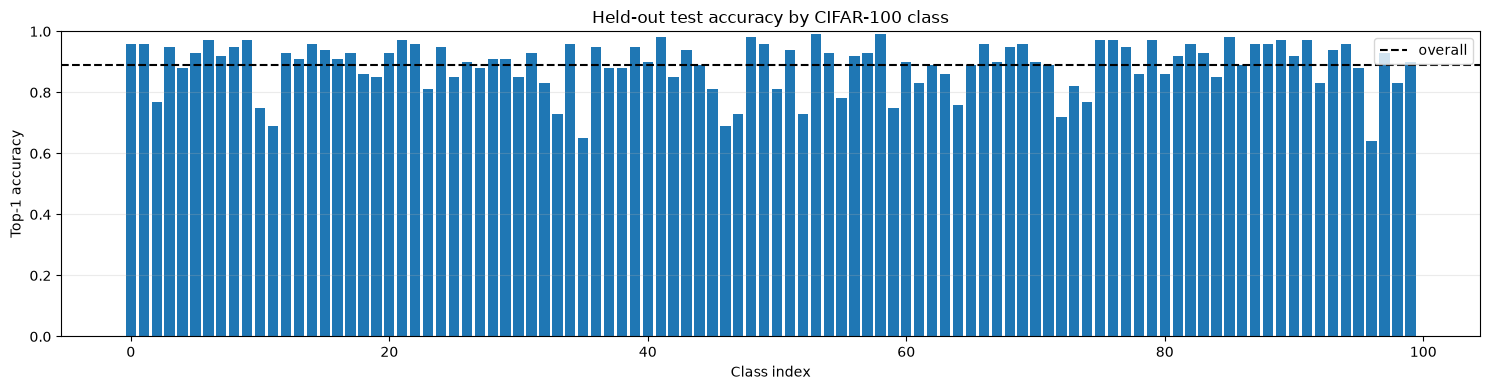

96 willow_tree          64.0%
35 girl                 65.0%
46 man                  69.0%
11 boy                  69.0%
72 seal                 72.0%
52 oak_tree             73.0%
33 forest               73.0%
47 maple_tree           73.0%
59 pine_tree            75.0%
10 bowl                 75.0%


In [11]:
confusion = np.zeros((100, 100), dtype=np.int64)
np.add.at(confusion, (test_arrays["targets"], test_arrays["predictions"]), 1)
class_totals = confusion.sum(axis=1)
class_accuracy = np.divide(
    np.diag(confusion),
    class_totals,
    out=np.full(100, np.nan),
    where=class_totals > 0,
)

fig, axis = plt.subplots(figsize=(15, 4))
axis.bar(np.arange(100), class_accuracy)
axis.axhline(test_metrics["top1_accuracy"], color="black", linestyle="--", label="overall")
axis.set(title="Held-out test accuracy by CIFAR-100 class", xlabel="Class index", ylabel="Top-1 accuracy", ylim=(0, 1))
axis.grid(axis="y", alpha=0.25)
axis.legend()
plt.tight_layout()
plt.show()

observed = np.flatnonzero(~np.isnan(class_accuracy))
weakest = observed[np.argsort(class_accuracy[observed])[:10]]
for class_id in weakest:
    print(f"{class_id:02d} {test_dataset.classes[class_id]:20s} {class_accuracy[class_id]:.1%}")


## Reading the result

- Use **full test top-1 accuracy** as the clean CIFAR-100 benchmark. Top-5 accuracy is useful context but does not replace top-1.
- If top-1 is below 90%, that is still a valid baseline result. Record it before changing the recipe.
- A clean-data score near 90% does not establish reliable confidence, corruption robustness, OOD rejection, or 90–95% accuracy among admitted predictions.
- Keep `calibration_outputs_full.npz` for fitting temperature scaling and later SDM components. Do not tune against `test_outputs_full.npz`.

Next experiments should evaluate softmax confidence and temperature scaling, then add CIFAR-100-C and SVHN before comparing SDM risk-coverage behavior.
